# Lib


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import joblib
from skimage.feature import local_binary_pattern
from tqdm import tqdm

from face_recognition import *

import warnings

warnings.filterwarnings("ignore")

# Path


In [2]:
TRAIN_DIR = "../../dataset_face_recognition/train"
TEST_DIR = "../../dataset_face_recognition/test"
RAW_DIR = "../../dataset_face_recognition/raw"
PREPROCESSED_DIR_TRAIN = "../../dataset_face_recognition/processed/train"
PREPROCESSED_DIR_TEST = "../../dataset_face_recognition/processed/test"
TRAIN_DIR = Path(TRAIN_DIR)
TEST_DIR = Path(TEST_DIR)
RAW_DIR = Path(RAW_DIR)
PREPROCESSED_DIR_TRAIN = Path(PREPROCESSED_DIR_TRAIN)
PREPROCESSED_DIR_TEST = Path(PREPROCESSED_DIR_TEST)

In [3]:
print(TRAIN_DIR)
print(TEST_DIR)
print(RAW_DIR)
print(PREPROCESSED_DIR_TRAIN)
print(PREPROCESSED_DIR_TEST)

..\..\dataset_face_recognition\train
..\..\dataset_face_recognition\test
..\..\dataset_face_recognition\raw
..\..\dataset_face_recognition\processed\train
..\..\dataset_face_recognition\processed\test


# Utils


In [4]:
def load_data(data_dir: Path):
    X = []
    y = []
    class_names = []

    classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

    for label_int, person_name in enumerate(classes):
        class_names.append(person_name)
        person_dir = data_dir / person_name

        for img_path in person_dir.glob("*.*"):
            if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue

            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X.append(img)
                y.append(label_int)

    return X, np.array(y), class_names

## Data


In [5]:
print("Train preprocessed data:")
X_train, y_train, class_names = load_data(PREPROCESSED_DIR_TRAIN)
print(f"Total images train: {len(X_train)} | classes: {len(class_names)}")

print("\nTest preprocessed data:")
X_test, y_test, class_names_test = load_data(PREPROCESSED_DIR_TEST)
print(f"Total images test: {len(X_test)} | classes: {len(class_names_test)}")

Train preprocessed data:
Total images train: 2388 | classes: 31

Test preprocessed data:
Total images test: 913 | classes: 31


# Visualization


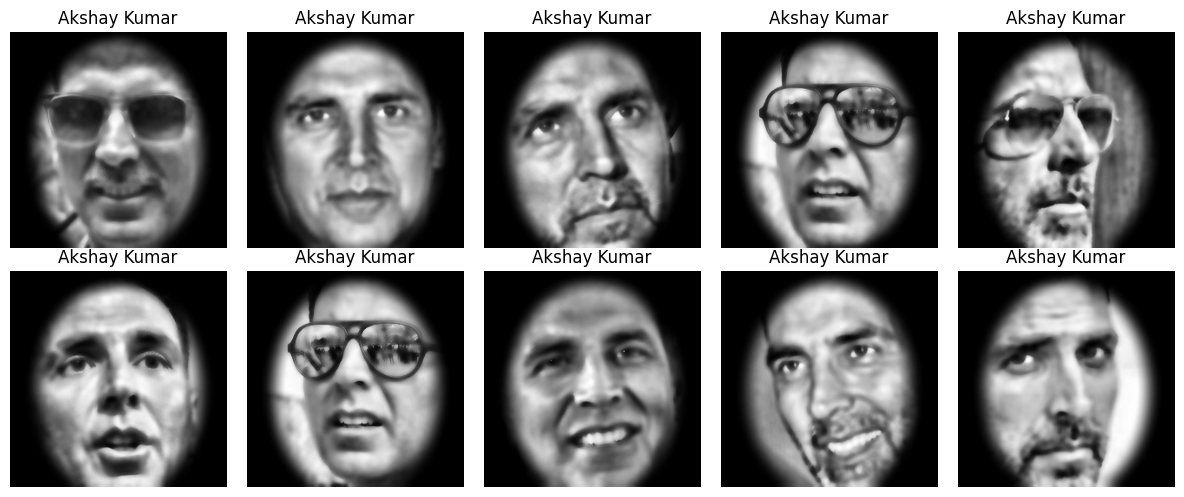

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = X_train[i]

    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

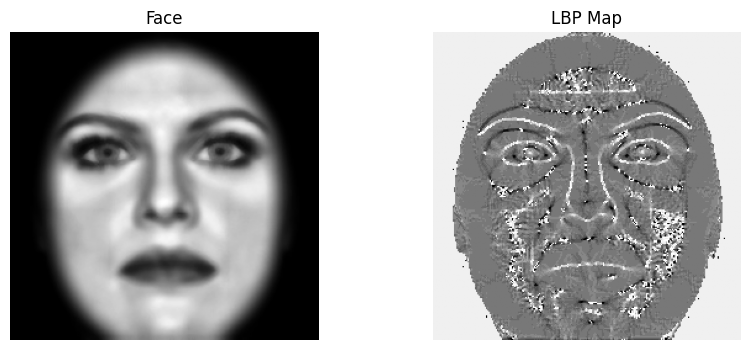

In [7]:
radius = 2
n_points = 8 * radius

img = X_train[100]

lbp = local_binary_pattern(img, n_points, radius, method="uniform")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Face")
ax[0].axis("off")

ax[1].imshow(lbp, cmap="gray")
ax[1].set_title("LBP Map")
ax[1].axis("off")

plt.show()

In [8]:
radius = 2
neighbors = 8

lbp = local_binary_pattern(img, neighbors, radius, method="uniform")

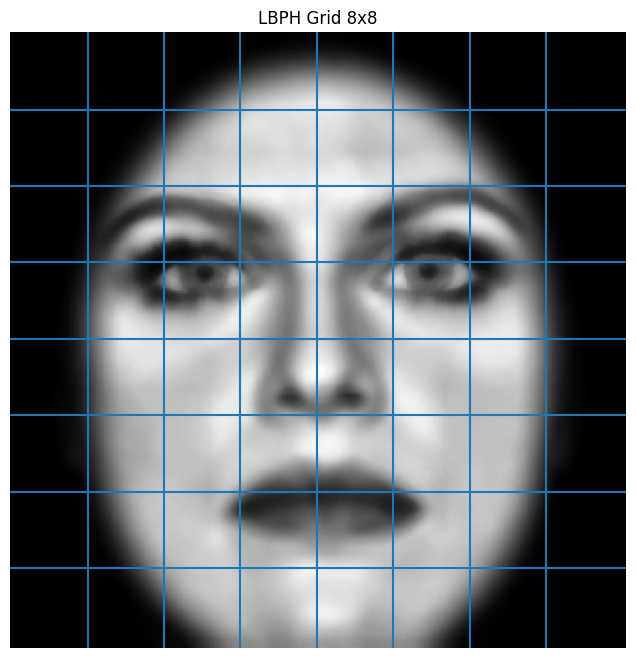

In [9]:
grid_x = 8
grid_y = 8

h, w = img.shape

cell_w = w // 8
cell_h = h // 8

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")

for x in range(1, 8):
    plt.axvline(x * cell_w)

for y in range(1, 8):
    plt.axhline(y * cell_h)

plt.title("LBPH Grid 8x8")
plt.axis("off")
plt.show()

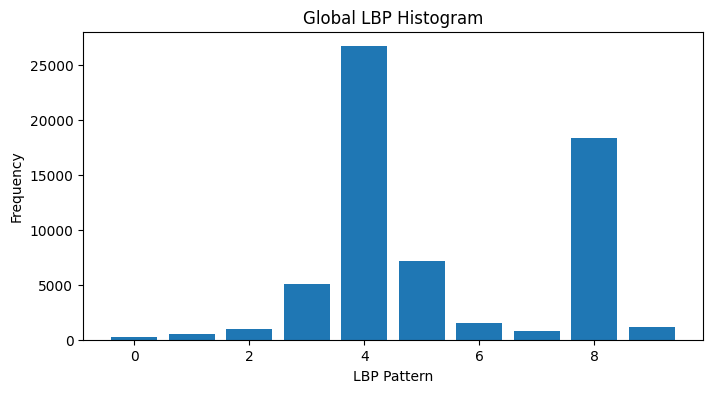

In [10]:
hist, bins = np.histogram(
    lbp.ravel(), bins=np.arange(0, neighbors + 3), range=(0, neighbors + 2)
)

plt.figure(figsize=(8, 4))
plt.bar(range(len(hist)), hist)
plt.title("Global LBP Histogram")
plt.xlabel("LBP Pattern")
plt.ylabel("Frequency")
plt.show()

In [11]:
grid_x = 8
grid_y = 8

cell_w = w // grid_x
cell_h = h // grid_y

for row in range(grid_y):
    for col in range(grid_x):

        region = lbp[
            row * cell_h : (row + 1) * cell_h, col * cell_w : (col + 1) * cell_w
        ]

        hist, _ = np.histogram(
            region.ravel(), bins=np.arange(0, neighbors + 3), range=(0, neighbors + 2)
        )

        print(f"\nRegion ({row},{col})")
        print(hist)


Region (0,0)
[  0   0   0   0   0   0   0   0 961   0]

Region (0,1)
[  0   0   0   8   8   4   3   0 938   0]

Region (0,2)
[  0   0   0  14 480  21   3   0 442   1]

Region (0,3)
[  0   5   1  12 788  61   5   5  78   6]

Region (0,4)
[  3   6   9  49 734  85   3   5  63   4]

Region (0,5)
[  3   0   0  12 504  21   2   2 417   0]

Region (0,6)
[  1   0   0  10  17   5   4   0 924   0]

Region (0,7)
[  0   0   0   0   0   0   0   0 961   0]

Region (1,0)
[  0   0   0   0   0   0   0   0 961   0]

Region (1,1)
[  0   0   1  21 484  63   8   2 382   0]

Region (1,2)
[  4   2  24 181 579 124  23   7   2  15]

Region (1,3)
[ 14  12  42 119 323 244  79  33  40  55]

Region (1,4)
[ 11  13  24 162 379 241  66  23  13  29]

Region (1,5)
[  5   9  22 160 545 159  15   7   3  36]

Region (1,6)
[  2   0   8  52 490  76   3   3 327   0]

Region (1,7)
[  0   0   0   0   0   0   0   0 961   0]

Region (2,0)
[  2   0   0   1 101  18   0   0 839   0]

Region (2,1)
[  4  10  69 111 645  50  13  26  

In [12]:
hist_matrix = []

for row in range(grid_y):
    row_hist = []

    for col in range(grid_x):

        region = lbp[
            row * cell_h : (row + 1) * cell_h, col * cell_w : (col + 1) * cell_w
        ]

        hist, _ = np.histogram(
            region.ravel(), bins=np.arange(0, neighbors + 3), range=(0, neighbors + 2)
        )

        row_hist.append(hist)

    hist_matrix.append(row_hist)

hist_matrix = np.array(hist_matrix)
print(hist_matrix.shape)

(8, 8, 10)


In [13]:
feature_vector = []

for row in range(grid_y):
    for col in range(grid_x):

        region = lbp[
            row * cell_h : (row + 1) * cell_h, col * cell_w : (col + 1) * cell_w
        ]

        hist, _ = np.histogram(
            region.ravel(), bins=np.arange(0, neighbors + 3), range=(0, neighbors + 2)
        )

        feature_vector.extend(hist)

feature_vector = np.array(feature_vector)
print("Feature vector shape:", feature_vector.shape)

Feature vector shape: (640,)


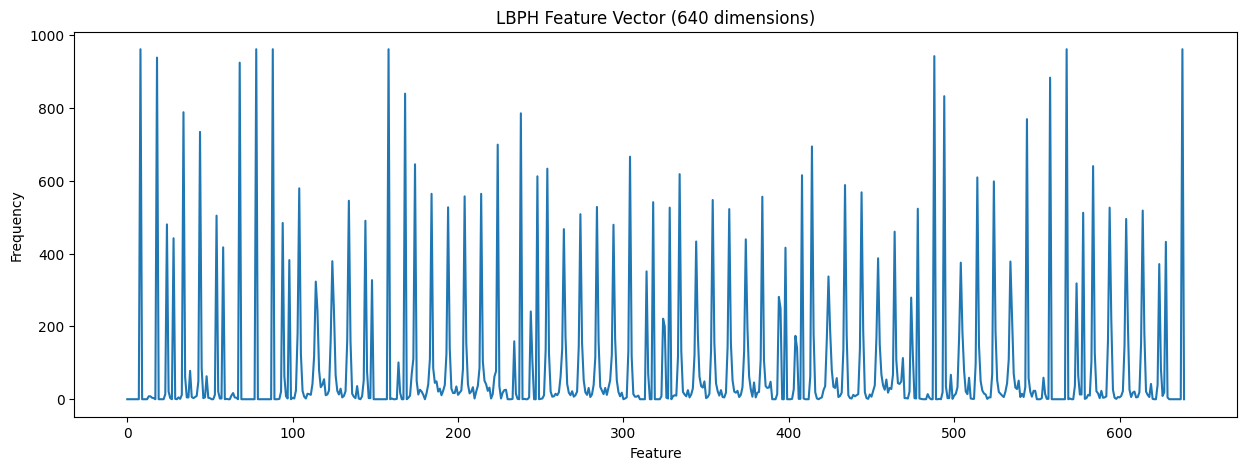

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(feature_vector)
plt.title("LBPH Feature Vector (640 dimensions)")
plt.xlabel("Feature")
plt.ylabel("Frequency")
plt.show()

# Train


In [15]:
lbph_model = cv2.face.LBPHFaceRecognizer_create(
    radius=2, neighbors=8, grid_x=8, grid_y=8
)

In [16]:
lbph_model.train(X_train, y_train)

# Eval


In [17]:
y_pred = []
distances = []
for img in tqdm(X_test, desc="Eval LBPH"):
    label, confidence = lbph_model.predict(img)
    y_pred.append(label)
    distances.append(confidence)
y_pred = np.array(y_pred)
y_prob = 1 - np.array(distances) / max(distances)

Eval LBPH: 100%|██████████| 913/913 [01:07<00:00, 13.47it/s]


In [18]:
print(classification_report(y_test, y_pred, target_names=class_names))

                    precision    recall  f1-score   support

      Akshay Kumar       1.00      0.89      0.94        18
Alexandra Daddario       0.97      0.97      0.97        34
        Alia Bhatt       0.97      0.93      0.95        30
  Amitabh Bachchan       1.00      0.96      0.98        24
      Andy Samberg       1.00      1.00      1.00        34
    Anushka Sharma       0.92      0.96      0.94        25
     Billie Eilish       0.96      0.89      0.93        28
         Brad Pitt       0.98      1.00      0.99        43
    Camila Cabello       1.00      0.93      0.97        30
   Charlize Theron       0.96      0.92      0.94        26
       Claire Holt       0.97      0.94      0.95        32
      Courtney Cox       0.97      1.00      0.98        28
    Dwayne Johnson       0.96      1.00      0.98        25
   Elizabeth Olsen       0.97      1.00      0.98        28
   Ellen Degeneres       0.96      1.00      0.98        27
      Henry Cavill       1.00      1.00

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

results_df = pd.DataFrame(
    {
        "Model": ["LBPH"],
        "accuracy": [accuracy],
        "precision": [precision],
        "recall": [recall],
        "f1-score": [f1],
    }
)
results_df.round(4)

,Model,accuracy,precision,recall,f1-score
0,LBPH,0.9759,0.9763,0.9759,0.9757


# Export


In [20]:
lbph_model_path = "../../model/lbph_model.yml"
lbph_model.write(lbph_model_path)